In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision

In [2]:
# dataset download -> dogs and cats

import os
os.environ["KAGGLE_API_TOKEN"] = "KGAT_2f4781ce33af65adb0875b91b7d64ef8"

!pip install -q --upgrade kaggle

""" Download the dataset """
!kaggle datasets download -d karakaggle/kaggle-cat-vs-dog-dataset

""""Unzip the downloaded file"""
import zipfile
print("Unzipping dataset...")
with zipfile.ZipFile("kaggle-cat-vs-dog-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data_clean")

""" Remove The zip container """
os.remove("kaggle-cat-vs-dog-dataset.zip")
print("Complete!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 14.1 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/karakaggle/kaggle-cat-vs-dog-dataset
License(s): unknown
100%|█████████████████████████████████████████| 787M/787M [00:05<00:00, 147MB/s]

Unzipping dataset...
Complete!


In [3]:
# Dataset folder define
data_folder_path = '/kaggle/working/data_clean/kagglecatsanddogs_3367a/PetImages'

In [4]:
# Removing broken file

from PIL import Image

for category in ['Cat', 'Dog']:
    folder_path = os.path.join(data_folder_path, category)
    
    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)

        # check for empty files or non-jpg items
        if os.path.getsize(file_path) == 0 or not filename.endswith('.jpg'):
            print(f"Removing broken/empty file: {file_path}")
            os.remove(file_path)
            continue

        # try opening to conform it isn't corrupted
        try:
            with Image.open(file_path) as img:
                img.verify()
        except (IOError, SyntaxError) as e:
            print(f"Removing corrupted image: {file_path}")
            os.remove("file_path")

print("All broken images cleaned up successfully!")


Removing broken/empty file: /kaggle/working/data_clean/kagglecatsanddogs_3367a/PetImages/Cat/Thumbs.db
Removing broken/empty file: /kaggle/working/data_clean/kagglecatsanddogs_3367a/PetImages/Dog/Thumbs.db


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


All broken images cleaned up successfully!


#### Overfitting remove: 1. Apply Aggressive Training Data Augmentation


In [5]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Dataset

# For traning : Makeing it hard for model to memorize
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),  # Flip left/right
    transforms.RandomRotation(degrees=15),   # Rotate slightly
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # change lighting
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# For validation: clean , here we don't agument
test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

# helper class ro apply different transforms to splits
class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform=transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

In [6]:
""" Dataset Split - Train & val"""
from torch.utils.data import DataLoader, random_split

# Load main dataset from main folder WITHOUT any transforms
base_dataset = datasets.ImageFolder(
    root=data_folder_path,
    transform=None
)

# calculate the 80/20 split sizes 
train_size = int(0.8 * len(base_dataset))
test_size = int(len(base_dataset) - train_size)

pure_train_subset, pure_test_subset = random_split(
    base_dataset, 
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_dataset = TransformedSubset(pure_train_subset, transform=train_transforms)
test_dataset = TransformedSubset(pure_test_subset, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=32, drop_last=True)

print(f"Total Images: {len(base_dataset)}")
print(f"Training Images: {len(train_dataset)}")
print(f"Validation Images: {len(test_dataset)}")

Total Images: 24959
Training Images: 19967
Validation Images: 4992


## Build CNN

### For Overfitting Remove: Add Dropout in Model

In [7]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # 1st LAyer: Feature Extractors
        # each Image size = 128x128
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(), # conv+ReLU: (128, 128, 3) => (128, 128, 16)
            # Max pooling layer (Downsample dimensions by half)
            nn.MaxPool2d(kernel_size=2, stride=2), # (64, 64, 16)
            # Size: 16 channels | 64x64

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(), # conv+ReLU: (64, 64, 16) => (64, 64, 32)
            nn.MaxPool2d(kernel_size=2, stride=2), # (32, 32, 32)
            # Size: 32 channels | 32x32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(), # conv+ReLU: (32, 32, 32) => (32, 32, 64)
            nn.MaxPool2d(kernel_size=2, stride=2) # (16, 16, 64)
            # Size: 64 channels | 16x16
        )

        # After Three Pooling, a 128x128 image becomes 16x16 (128 -> 64 -> 32 -> 16)
        # 64 channels * 16 * 16 pixels = 64*16*16 = 16384 fatures

        self.fc_layers = nn.Sequential(
            nn.Linear(64*16*16, 128), # inout, output 
            nn.ReLU(),

            nn.Linear(128, 2) # 2 output for binary classifaction: Cat or Dog
        )

        # Dropout add - for Overitting manage
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) # flatten the image tensor into a 1D vector
        x = self.dropout(x) # randomly turns off 50% of model neurons during training
        x = self.fc_layers(x) # logits for crossENtropyLoss

        return x

In [8]:
model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(model)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=16384, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
  (dropout): Dropout(p=0.5, inplace=False)
)


## For Overfitting remove: By Droping Learning Rate 
- traning loss that drops very first: means learning rate is **too high**
- so we change default **lr** to lr=0.0001

## For Overfitting remove: Inject Weight Decay (L2 Regularization)
- Weight decay penalizes the model for making its weights too large
- which naturally prevents it from fitting too tightly to the training noise.

In [9]:
criterian = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Model Train & validation

In [10]:
# Model Train & validation
print(f"Model train on {device}...")

train_losses = []
val_losses = []
best_val_loss = float("inf")

epochs = 10

for epoch in range(epochs):
    running_train_loss = 0.0
    model.train()
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        output = model(images) # FP
        loss = criterian(output, labels)
        loss.backward() # BP
        optimizer.step() # update params

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            
            output = model(images)
            loss = criterian(output, labels)
            running_val_loss += loss.item()

        epoch_val_loss = running_val_loss / len(test_loader)
        val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} - train_loss={epoch_train_loss} & val_loss={epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "DogCat_Classiify_best.pt")



Model train on cuda...
epoch 1/10 - train_loss=0.6182645419149108 & val_loss=0.5616456824235427
epoch 2/10 - train_loss=0.549752813950779 & val_loss=0.52962548018266
epoch 3/10 - train_loss=0.5236730234006818 & val_loss=0.5033079557693921
epoch 4/10 - train_loss=0.4968234546494522 & val_loss=0.47628444796189284
epoch 5/10 - train_loss=0.4792944768362979 & val_loss=0.47651491151788294
epoch 6/10 - train_loss=0.4606955619484043 & val_loss=0.4422057767709096
epoch 7/10 - train_loss=0.4470282742577227 & val_loss=0.4240102873971829
epoch 8/10 - train_loss=0.4359281574215973 & val_loss=0.4208595921786932
epoch 9/10 - train_loss=0.4212945807802926 & val_loss=0.4024543109803628
epoch 10/10 - train_loss=0.41540024509686335 & val_loss=0.3912787088790001


Text(0, 0.5, 'Losses')

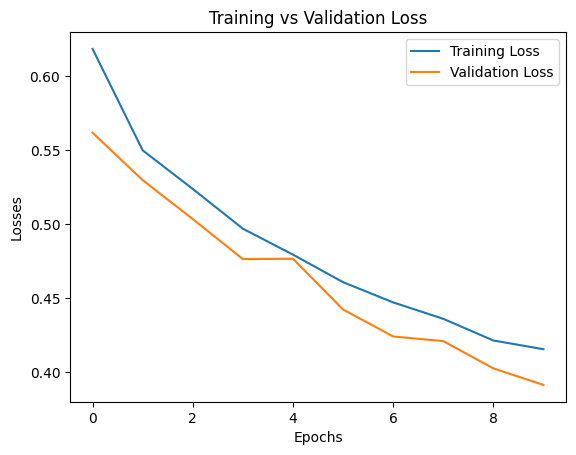

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses,
})

plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.legend()

plt.xlabel("Epochs")
plt.ylabel("Losses")

In [12]:
# Validation

model.eval()
total = 0
correct = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Total data = {total}")
print(f"Correct prediction = {correct}")
print(f"Test Accuracy: {100 * correct / total:.2f}%") 

Total data = 4992
Correct prediction = 4111
Test Accuracy: 82.35%
